# Contrails.org forecasts

Contrails.org forecasts are available through the [Contrails.org API](https://apidocs.contrails.org/notebooks/forecast_api.html). Access is free but requires an [API key](https://apidocs.contrails.org/access.html).

This notebook shows
1. How to access Contrails.org forecasts with asynchronous HTTP requests (convenient when requesting large amounts of data)
2. How to preprocess Contrails.org forecasts into the format expected by ContrailBench PCR benchmarks

Note that the Contrails.org API provides forecasts starting June 1 2024. If you want access to historical Contrails.org forecasts before this date (e.g., to reproduce ContrailBench results that include dates before June 1 2024), please contact [info@contrails.org](mailto:info@contrails.org).

## Accessing Contrails.org forecasts

In [13]:
import datetime
import os

import aiohttp
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib import colors

Forecast time and flight level are specified as query parameters. ContrailBench uses the default aircraft type and raw [energy forcing](https://apidocs.contrails.org/ef-interpretation.html) values.

In [2]:
time = datetime.datetime(2024, 6, 1, 0)
flight_level = 350

url = "https://api.contrails.org/v1/grids"
params = {
    "aircraft_class": "default",
    "flight_level": str(flight_level),
    "time": time.strftime("%Y-%m-%dT%H"),
    "units": "ef_per_m",
}
headers = {"x-api-key": os.environ["CONTRAILS_API_KEY"]}

async with (
    aiohttp.ClientSession(raise_for_status=True) as session,
    session.get(url, params=params, headers=headers) as resp,
):
    content = await resp.read()

The Contrails.org API returns gridded forecasts as netCDF file. These can be opened using xarray after saving to disk.

In [3]:
with open("forecast.nc", "wb") as f:
    f.write(content)

ds = xr.open_dataset("forecast.nc")

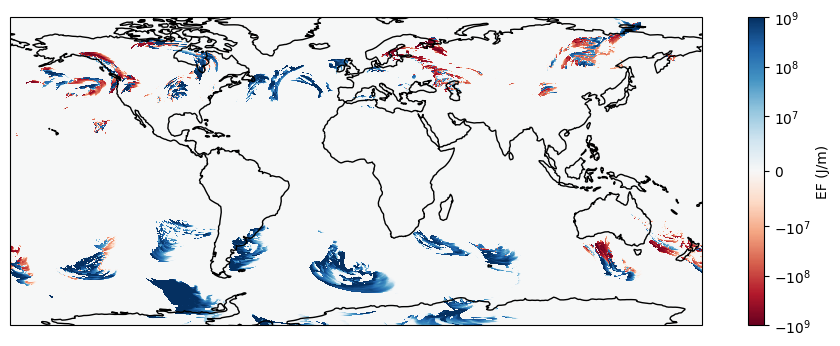

In [29]:
plt.figure(figsize=(12, 4))
ax = plt.subplot(111, projection=ccrs.PlateCarree())
im = ax.pcolormesh(
    ds["longitude"],
    ds["latitude"],
    ds["ef_per_m"].squeeze().T,
    shading="nearest",
    cmap="RdBu",
    norm=colors.SymLogNorm(linthresh=1e7, vmin=-1e9, vmax=1e9),
    transform=ccrs.PlateCarree(),
)
plt.colorbar(im, ax=ax, label="EF (J/m)")
ax.coastlines();

## Preprocessing Contrails.org forecasts

The Contrails.org forecast is deterministic, so ContrailBench PCR benchmarks require a processed forecast with a binary PCR region flag.

The odds that a persistent contrail produces exactly zero EF are tiny, so we set the PCR region flag to 1 in regions where forecast EF is nonzero.

In [33]:
ds["pcr"] = ds["ef_per_m"] != 0
processed = ds[["pcr"]]

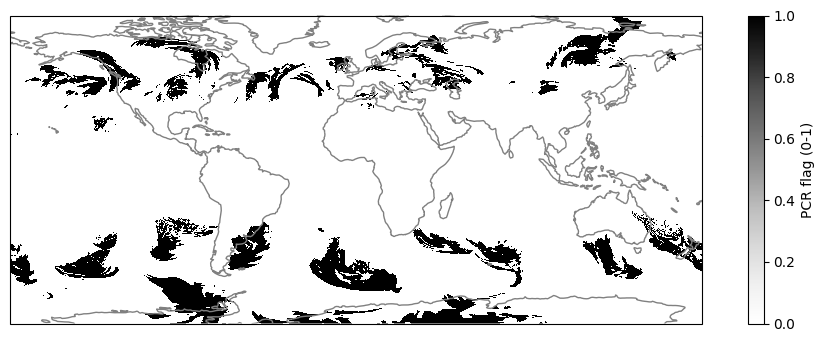

In [39]:
plt.figure(figsize=(12, 4))
ax = plt.subplot(111, projection=ccrs.PlateCarree())
im = ax.pcolormesh(
    processed["longitude"],
    processed["latitude"],
    processed["pcr"].squeeze().T,
    shading="nearest",
    cmap="Greys",
    transform=ccrs.PlateCarree(),
)
plt.colorbar(im, ax=ax, label="PCR flag (0-1)")
ax.coastlines(color="gray");